# Common

In [24]:
import numpy as np
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional
import warnings
import sys

In [25]:
np.set_printoptions(threshold=sys.maxsize, linewidth=150)

# Requires Functions

In [26]:
@dataclass
class PlotParams:
    
    linestyle:  str = "-"
    color:      str = "k"
    linewidth:  float = 1.0
    marker:     Optional[str] = None
    markersize: float = 1.0
    label:      str = ""
    capsize:    float = 3.0
    markevery:  int = 1

class Plotter:

    def __init__(self, title: str = None, xlabel: str = None, ylabel: str = None, figsize: tuple = (16, 9)):
        
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.ax.set_title(title, fontsize=20, pad=30)
        self.ax.set_xlabel(xlabel, fontsize=18, labelpad=20)
        self.ax.set_ylabel(ylabel, fontsize=18, labelpad=20)

    def add_plot(self, x: np.ndarray, y: np.ndarray, params: PlotParams):

        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
            marker      = params.marker,
            markersize  = params.markersize,
            markevery   = params.markevery
        )

    def finalize_and_show(self, save_path: Optional[str] = None):

        self.ax.minorticks_on()
        self.ax.grid(True, which='both', linestyle='--', alpha=0.3)
        self.ax.legend(fontsize=14, loc='best', frameon=True, fancybox=True, framealpha=0.9)
        self.ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.5)
        self.ax.tick_params(axis='both', which='minor', length=4, width=1)
        self.fig.tight_layout()

        if save_path:
            self.fig.savefig(save_path)
            print(f"График сохранен в файл: {save_path}")

        plt.show()
        plt.close(self.fig)

In [27]:
# Helper

def _get_stop_threshold(b_norm, atol=0., rtol=1e-5):
    
    return max(atol, rtol * b_norm)

In [28]:
def solve_triangular(A, b, type=None):
    """
    Решает систему A @ X = B для треугольной матрицы A.

    См. https://books.mipt.ru/book/301568
    
    Parameters
    ----------
    A : (M, M) ndarray
        Треугольная матрица (нижняя или верхняя).
    b : (M,) or (M, K) array_like
        Вектор или матрица правых частей.
    type : {'lower', 'upper'}
        Тип треугольной матрицы A.
        - 'lower' : (по умолчанию) A - нижнетреугольная, используется прямая подстановка.
        - 'upper' : A - верхнетреугольная, используется обратная подстановка.
    
    Returns
    -------
    x : (M,) or (M, K) ndarray
        Решение системы. Форма результата соответствует форме b.
    """
    # --- 1. Обработка входных данных ---
    A = np.asarray(A, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    is_vector = b.ndim == 1
    if is_vector:
        # Временно преобразуем вектор в матрицу-столбец для универсальности
        b = b.reshape(-1, 1)

    if A.shape[0] != A.shape[1]:
        raise ValueError("Матрица A должна быть квадратной.")
    if A.shape[0] != b.shape[0]:
        raise ValueError("Несовместимые размеры A и b.")

    # --- 2. Основной алгоритм ---
    n = A.shape[0]
    x = b.copy()

    if type == 'lower':
        # Прямая подстановка (forward substitution)
        for i in range(n):
            dot_product = np.dot(A[i, :i], x[:i])
            x[i] = (x[i] - dot_product) / A[i, i]
    
    elif type == 'upper':
        # Обратная подстановка (backward substitution)
        for i in range(n - 1, -1, -1):
            dot_product = np.dot(A[i, i+1:], x[i+1:])
            x[i] = (x[i] - dot_product) / A[i, i]
    
    else:
        raise ValueError("Параметр 'type' должен быть 'lower' или 'upper'.")

    # --- 3. Возврат результата в исходной форме ---
    if is_vector:
        return x.ravel() # Превращаем (M, 1) обратно в (M,)
    else:
        return x

In [29]:
def solve_gauss(A, b, pivoting='full'):
    """
    Решает систему A @ x = b методом Гаусса с выбором главного элемента.
    Может работать как с вектором b, так и с матрицей правых частей B.

    См. https://books.mipt.ru/book/301568
    
    Parameters
    ----------
    A : (M, M) array_like
        Квадратная матрица коэффициентов
    b : (M,) array_like
        Вектор или матрица правых частей
    pivoting : {'full', 'partial'}
        Стратегия выбора главного элемента:
        - 'full' : поиск по всей подматрице (default)
        - 'partial' : поиск по столбцу
    
    Returns
    -------
    x : (M,) or (M, K) ndarray
        Решение системы. Форма результата соответствует форме b.
    """
    # np.result_type гарантирует, что если A или b комплексные, то dtype будет complex
    # Если оба float/int, то dtype будет float64
    dtype = np.result_type(A, b, np.float64)
    A = np.asarray(A, dtype=dtype)
    b = np.asarray(b, dtype=dtype)

    # --- Обработка формы входных/выходных данных ---
    is_vector = b.ndim == 1
    if is_vector:
        # Временно преобразуем вектор в матрицу-столбец для универсальности
        b = b.reshape(-1, 1)
    
    if A.shape[0] != A.shape[1]:
        raise ValueError("Матрица должна быть квадратной")
    if A.shape[0] != b.shape[0]:
        raise ValueError("Несовместимые размеры A и b")
    
    n = A.shape[0]
    A = A.copy()
    b_copy = b.copy()
    
    # Проверка на сингулярность
    matrix_max_abs = np.max(np.abs(A))
    
    singularity_threshold = matrix_max_abs * np.finfo(np.float64).eps * n

    if matrix_max_abs < singularity_threshold:
        raise ValueError(
            f"Singular matrix, abs(A[{n-1}, {n-1}])="
            f"{np.abs(A[n-1, n-1])}, "
            f"threshold={singularity_threshold}"
        )
    
    # Вектор перестановок для отслеживания порядка переменных при pivoting == 'full'
    # permutations[i] = j означает, что i-й столбец соответствует переменной x_j
    permutations = np.arange(n)
    
    # --- Прямой ход ---
    
    for pivot_idx in range(n - 1):
        pivot_row, pivot_col = pivot_idx, pivot_idx
        
        # --- Этап 1: Поиск ведущего элемента ---
        
        if pivoting == 'partial':
            # Поиск максимума в текущем столбце, начиная с pivot_idx-й строки
            sub_matrix = A[pivot_idx:, pivot_idx]
            relative_row_idx = np.argmax(np.abs(sub_matrix))
            pivot_row = pivot_idx + relative_row_idx

        elif pivoting == 'full':
            # Поиск максимума в оставшейся подматрице
            sub_matrix = A[pivot_idx:, pivot_idx:]
            relative_row_idx, relative_col_idx = np.unravel_index(
                np.argmax(np.abs(sub_matrix)), 
                sub_matrix.shape
            )
            pivot_row = pivot_idx + relative_row_idx
            pivot_col = pivot_idx + relative_col_idx
            
        else:
            raise ValueError('Некорректная стратегия pivoting')
        
        # --- Этап 2: Перестановки ---
        
        if pivot_row != pivot_idx:  # Перестановка строк
            A[[pivot_idx, pivot_row], :] = A[[pivot_row, pivot_idx], :]
            b_copy[[pivot_idx, pivot_row]] = b_copy[[pivot_row, pivot_idx]]
        
        if pivoting == 'full' and pivot_col != pivot_idx:  # Перестановка столбцов
            A[:, [pivot_idx, pivot_col]] = A[:, [pivot_col, pivot_idx]]
            permutations[[pivot_idx, pivot_col]] = permutations[[pivot_col, pivot_idx]]
        
        # Проверка на вырожденность
        if np.abs(A[pivot_idx, pivot_idx]) < singularity_threshold:
            raise ValueError(
                f"Singular matrix, abs(A[{pivot_idx}, {pivot_idx}])="
                f"{np.abs(A[pivot_idx, pivot_idx])}, "
                f"threshold={singularity_threshold}"
            )
        
        # --- Этап 3: Обнуление элементов под ведущим ---
        
        factors = A[pivot_idx+1:, pivot_idx] / A[pivot_idx, pivot_idx]
        A[pivot_idx+1:, pivot_idx:] -= np.outer(factors, A[pivot_idx, pivot_idx:])
        
        # --- Использование broadcasting для матрицы b_copy (чтобы работало, если b_copy - матрица) ---
        b_copy[pivot_idx+1:] -= factors[:, np.newaxis] * b_copy[pivot_idx]
    
    # Проверка на вырожденность последнего элемента
    if np.abs(A[n - 1, n - 1]) < singularity_threshold:
        raise ValueError(
            f"Singular matrix, abs(A[{n-1}, {n-1}])="
            f"{np.abs(A[n-1, n-1])}, "
            f"threshold={singularity_threshold}"
        )
    
    # --- Обратный ход ---
    
    x_solution = solve_triangular(A, b_copy, type='upper')
    
    # --- Восстановление порядка и формы ---
    if pivoting == 'full':
        sorted_x = np.zeros_like(x_solution)
        sorted_x[permutations] = x_solution
        final_solution = sorted_x
    else:
        final_solution = x_solution
        
    # --- Возвращаем результат в исходной форме ---
    if is_vector:
        return final_solution.reshape(-1) # Превращаем (M, 1) обратно в (M,)
    else:
        return final_solution

In [30]:
def solve_lu(PLU, b):
    """
    Решает систему уравнений используя P, L, U разложение (PA=LU).

    мы решаем систему A @ x = b.
    Из разложения мы знаем, что P @ A = L @ U.
    Умножим исходное уравнение слева на P:
    P @ A @ x = P @ b
    (L @ U) @ x = P @ b

    См. https://en.wikipedia.org/wiki/LU_decomposition
    
    Parameters
    ----------
    PLU : tuple (P, L, U)
        Результат от функции lu_factor():
        - P : (M, M) ndarray - матрица перестановок
        - L : (M, M) ndarray - нижняя треугольная матрица
        - U : (M, M) ndarray - верхняя треугольная матрица
    b : (M,) array_like
        Вектор правой части
    
    Returns
    -------
    x : (M,) ndarray
        Решение системы
    """
    P, L, U = PLU
    b = np.asarray(b, dtype=np.float64)
    
    # Шаг 1: Решаем L @ y = P @ b с помощью прямой подстановки.
    b_permuted = P @ b
    y = solve_triangular(L, b_permuted, type='lower')
    
    # Шаг 2: Решаем U @ x = y с помощью обратной подстановки.
    x = solve_triangular(U, y, type='upper')
    
    return x

def lu_factor(A):
    """
    Вычисляет LU разложение с перестановками. P @ A = L @ U.
    
    Реализует алгоритм PLU разложения с частичным выбором
    главного элемента по столбцу (partial pivoting).
    
    Parameters
    ----------
    A : (M, M) array_like
        Матрица для разложения
    
    Returns
    -------
    P : (M, M) ndarray
        Матрица перестановок
    L : (M, M) ndarray
        Нижняя треугольная матрица с единичной диагональю
    U : (M, M) ndarray
        Верхняя треугольная матрица
    
    Notes
    -----
    Разложение: P @ A = L @ U
    """
    # --- Этап 1: Инициализация и подготовка ---
    A = np.asarray(A)
    if A.shape[0] != A.shape[1]:
        raise ValueError("Матрица должна быть квадратной")
    
    n = A.shape[0]
    
    # Создаем копию матрицы, которая будет преобразована в компактную LU форму
    lu_matrix = A.copy()
    
    # Инициализируем вектор перестановок
    piv = np.arange(n)
    
    # Порог для определения сингулярности
    matrix_max_abs = np.max(np.abs(A))
    if matrix_max_abs == 0:
        raise ValueError("Singular matrix")
    singularity_threshold = matrix_max_abs * np.finfo(np.float64).eps * n

    # --- Этап 2: Основной цикл разложения ---
    for k in range(n - 1):
        # Поиск главного элемента (частичный выбор)
        i_max = k + np.argmax(np.abs(lu_matrix[k:, k]))
        
        if i_max != k:
            # Перестановка строк в нашей рабочей матрице
            lu_matrix[[k, i_max], :] = lu_matrix[[i_max, k], :]
            # Запоминаем перестановку в векторе piv
            piv[[k, i_max]] = piv[[i_max, k]]
        
        # Проверка на вырожденность
        pivot_element = lu_matrix[k, k]
        if abs(pivot_element) < singularity_threshold:
            raise ValueError(f"Singular matrix, pivot at index {k} is near zero.")
        
        # Вычисление множителей для L и сохранение их на месте
        factors = lu_matrix[k+1:, k] / pivot_element
        lu_matrix[k+1:, k] = factors
        
        # Обновление оставшейся подматрицы
        lu_matrix[k+1:, k+1:] -= np.outer(factors, lu_matrix[k, k+1:])
    
    # --- Этап 3: Формирование явных матриц P, L, U ---
    
    # L: нижняя треугольная с единичной диагональю
    L = np.tril(lu_matrix, k=-1) + np.eye(n, dtype=np.float64)
    
    # U: верхняя треугольная
    U = np.triu(lu_matrix)
    
    # P: матрица перестановок, созданная из вектора piv
    P = np.eye(n, dtype=np.float64)[piv, :]
    
    return P, L, U

In [31]:
def inverse(A):
    """
    Вычисляет обратную матрицу A^-1 используя LU разложение.

    Parameters
    ----------
    A : (M, M) array_like
        Квадратная матрица
    Returns
    -------
    A_inv : (M, M) ndarray
        Обратная матрица A^-1
    """
    return solve_lu(lu_factor(A), np.eye(A.shape[0]))

# Итерационные методы

In [32]:
def solve_jacobi(A, b, x0=None, rtol=1e-5, atol=1e-8, maxiter=1000):
    """
    Решает систему A @ x = b методом Якоби.

    Формула итерации: x^(k+1) = - D⁻¹ @ (L + U) @ x^(k) + D⁻¹ @ b = D⁻¹ @ (b - (L + U) @ x^(k))
    где A = L + D + U.

    См. https://books.mipt.ru/book/301568

    Parameters
    ----------
    A : (M, M) array_like
        Квадратная матрица коэффициентов системы.
    b : (M,) array_like
        Вектор правой части.
    x0 : (M,) array_like, optional
        Начальное приближение. Если None, используется нулевой вектор.
    rtol, atol : float, optional
        Относительная и абсолютная погрешности для критерия остановки.
    maxiter : int, optional
        Максимальное количество итераций.

    Returns
    -------
    x : (M,) ndarray
        Найденное решение системы.
    info : int
        Информация о сходимости:
            >0  : успешный выход (решение найдено с заданной точностью).
            0 : сходимость не достигнута за `maxiter` итераций.
    r_norm_arr: List[float]
        История нормы невязки на каждой итерации.
    """
    # --- Этап 1: Инициализация и декомпозиция ---
    A = np.asarray(A, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    b_norm = np.linalg.norm(b)
    stop_threshold = _get_stop_threshold(b_norm, atol=atol, rtol=rtol)

    if A.shape[0] != A.shape[1]:
        raise ValueError("Матрица A должна быть квадратной.")
    
    n = A.shape[0]

    if x0 is None:
        x = np.zeros(n, dtype=np.float64)
    else:
        x = np.asarray(x0, dtype=np.float64).copy()

    # Декомпозиция матрицы A = L + D + U
    diag_A_vec = np.diag(A)
    if np.any(np.isclose(diag_A_vec, 0)):
        raise ValueError("Метод не применим: на главной диагонали есть нулевые элементы.")
    
    # D_inv - это матрица с 1/diag_A на диагонали. Вычислять полную D и затем
    # обращать ее через np.linalg.inv() крайне неэффективно.
    D_inv = np.diag(1 / diag_A_vec)
    
    # L_plus_U - это матрица A без диагонали
    L_plus_U = A - np.diag(diag_A_vec)

    # История нормы невязки
    r_norm_arr = []

    # --- Этап 2: Основной итерационный цикл ---
    for iter_counter in range(maxiter):
        
        # x_new = D_inv @ (b - (L+U) @ x_old)
        x = D_inv @ (b - L_plus_U @ x)
        
        # Проверка критерия остановки
        r_norm = np.linalg.norm(A @ x - b)
        r_norm_arr.append(r_norm)
        if r_norm < stop_threshold:
            return x, iter_counter + 1, r_norm_arr  # Успешный выход
            
    return x, 0, r_norm_arr  # Сходимость не достигнута


In [33]:
def solve_sor(A, b, omega, x0=None, rtol=1e-5, atol=1e-8, maxiter=1000):
    """
    Решает систему A @ x = b методом последовательной верхней релаксации (SOR).

    Метод SOR является обобщением метода Гаусса-Зейделя и часто сходится
    быстрее при правильном выборе параметра релаксации omega.

    Parameters
    ----------
    A : (M, M) array_like
        Квадратная матрица коэффициентов системы.
    b : (M,) array_like
        Вектор правой части.
    omega : float
        Параметр релаксации. Для сходимости необходимо 0 < omega < 2.
    x0 : (M,) array_like, optional
        Начальное приближение. Если None, используется нулевой вектор.
    rtol, atol : float, optional
        Относительная и абсолютная погрешности для критерия остановки.
    maxiter : int, optional
        Максимальное количество итераций.

    Returns
    -------
    x : (M,) ndarray
        Найденное решение системы.
    info : int
        Информация о сходимости:
            >0  : успешный выход (решение найдено с заданной точностью).
            0 : сходимость не достигнута за `maxiter` итераций.
    r_norm_arr: List[float]
        История нормы невязки на каждой итерации.

    Notes
    -----

    См. https://books.mipt.ru/book/301568
    
    Матрица A раскладывается на составляющие: A = D + L + U, где:
    - D : диагональная часть A
    - L : строго нижнетреугольная часть A (элементы под диагональю)
    - U : строго верхнетреугольная часть A (элементы над диагональю)

    Итерационная формула имеет вид:
        (D + ωL) @ x^(k+1) = ((1 - ω)D - ωU) @ x^k + ωb

    Матрицы для левой и правой частей
    (M = D + ωL и N = (1 - ω)D - ωU) вычисляются заранее перед циклом.
    """
    # --- Этап 1: Инициализация и проверки ---
    A = np.asarray(A, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    b_norm = np.linalg.norm(b)
    stop_threshold = _get_stop_threshold(b_norm, atol=atol, rtol=rtol)

    if A.shape[0] != A.shape[1]:
        raise ValueError("Матрица A должна быть квадратной.")
    if not (0 < omega < 2):
        raise ValueError("Параметр omega должен быть в интервале (0, 2).")

    n = A.shape[0]

    if x0 is None:
        x = np.zeros(n, dtype=np.float64)
    else:
        x = np.asarray(x0, dtype=np.float64).copy()

    # --- Этап 2: Предварительное вычисление матриц для итераций ---
    D = np.diag(np.diag(A))
    if np.any(np.isclose(np.diag(D), 0)):
        raise ValueError("Метод не применим: на главной диагонали есть нулевые элементы.")
        
    L = np.tril(A, k=-1)
    U = np.triu(A, k=1)

    # M @ x^(k+1) = N @ x^k + c
    M = D + omega * L
    N = (1 - omega) * D - omega * U
    c = omega * b

    # История нормы невязки
    r_norm_arr = []
    
    # --- Этап 3: Основной итерационный цикл ---
    for iter_counter in range(maxiter):
        
        # Решаем нижнетреугольную систему M @ x = N @ x_old + c
        x = solve_triangular(M, N @ x + c, type='lower')

        r_norm = np.linalg.norm(A @ x - b)
        r_norm_arr.append(r_norm)

        # Проверка критерия остановки
        if r_norm < stop_threshold:
            return x, iter_counter + 1, r_norm_arr  # Успешный выход
            
    return x, 0, r_norm_arr  # Не сошлось за maxiter

In [34]:
def solve_seidel(A, b, x0=None, rtol=1e-5, atol=1e-8, maxiter=1000):
    """
    Решает систему A @ x = b методом Гаусса-Зейделя.

    Эта функция является оберткой для solve_sor,
    вызывая его с параметром релаксации omega = 1, что в точности
    соответствует методу Гаусса-Зейделя.

    Parameters
    ----------
    A : (M, M) array_like
        Квадратная матрица коэффициентов системы.
    b : (M,) array_like
        Вектор правой части.
    x0 : (M,) array_like, optional
        Начальное приближение. Если None, используется нулевой вектор.
    rtol, atol : float, optional
        Относительная и абсолютная погрешности для критерия остановки.
    maxiter : int, optional
        Максимальное количество итераций.

    Returns
    -------

    См. https://books.mipt.ru/book/301568

    x : (M,) ndarray
        Найденное решение системы.
    info : int
        Информация о сходимости, возвращаемая из solve_sor.
    r_norm_arr: List[float]
        История нормы невязки на каждой итерации, возвращаемая из solve_sor.
    """
    # Просто вызываем solve_sor с фиксированным значением omega = 1.0
    return solve_sor(A, b, omega=1.0, x0=x0, rtol=rtol, atol=atol, maxiter=maxiter)

In [35]:
def solve_gradient_descent(A, b, x0=None, rtol=1e-5, atol=1e-8, maxiter=1000):
    """
    Решает систему A @ x = b методом наискорейшего градиентного спуска.

    Этот метод предназначен для систем, где матрица A является
    симметричной и положительно-определенной.

    Parameters
    ----------
    A : (M, M) array_like
        Симметричная положительно-определенная матрица коэффициентов.
    b : (M,) array_like
        Вектор правой части.
    x0 : (M,) array_like, optional
        Начальное приближение. Если None, используется нулевой вектор.
    rtol, atol : float, optional
        Относительная и абсолютная погрешности для критерия остановки.
    maxiter : int, optional
        Максимальное количество итераций.

    Returns
    -------
    x : (M,) ndarray
        Найденное решение системы.
    info : int
        Информация о сходимости:
            >0 : успешный выход (возвращается количество итераций).
            0  : сходимость не достигнута за `maxiter` итераций.
            -1 : матрица не является симметричной.
    r_norm_arr: List[float]
        История нормы невязки на каждой итерации.

    Notes
    -----

    См. https://books.mipt.ru/book/301568

    Итерационный процесс строится следующим образом:
    1. Вычисляется вектор невязки: r_k = A @ x_k - b
    2. Вычисляется оптимальный шаг: τ_k = (r_k.T @ r_k) / (r_k.T @ A @ r_k)
    3. Обновляется решение: x_{k+1} = x_k - τ_k * r_k
    Процесс повторяется до достижения заданной точности.
    """
    # --- Этап 1: Инициализация и проверки ---
    A = np.asarray(A, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    if A.shape[0] != A.shape[1]:
        raise ValueError("Матрица A должна быть квадратной.")

    # Проверка на симметричность - необходимое условие метода
    if not np.allclose(A, A.T):
        warnings.warn("Матрица не является симметричной. Метод градиентного спуска не применим.",
                      RuntimeWarning)
        return np.full_like(b, np.nan), -1

    n = A.shape[0]
    if x0 is None:
        x = np.zeros(n, dtype=np.float64)
    else:
        x = np.asarray(x0, dtype=np.float64).copy()

    # --- Этап 2: Основной итерационный цикл ---
    
    # Критерий остановки по невязке: ||A@x - b|| <= atol + rtol*||b||
    b_norm = np.linalg.norm(b)
    stop_threshold = _get_stop_threshold(b_norm, atol=atol, rtol=rtol)
    
    # Вычисляем начальную невязку
    r = A @ x - b

    r_norm_arr = []
    
    for iter_counter in range(maxiter):

        r_norm = np.linalg.norm(r)
        r_norm_arr.append(r_norm)
        
        # Проверка на сходимость в начале итерации
        if r_norm < stop_threshold:
            return x, iter_counter + 1, r_norm_arr # Успешный выход

        Ar = A @ r

        # tau = (r.T @ r) / (r.T @ A @ r)
        tau_numerator = np.dot(r, r)
        tau_denominator = np.dot(r, Ar)

        # Защита от деления на ноль, если r стал нулевым вектором
        if tau_denominator == 0:
            return x, iter_counter + 1, r_norm_arr # Решение найдено точно

        tau = tau_numerator / tau_denominator

        # Обновляем решение и невязку
        x = x - tau * r
        r = r - tau * Ar # Более эффективное обновление невязки

    r_norm = np.linalg.norm(r)
    r_norm_arr.append(r_norm)
            
    # Проверяем еще раз после цикла, вдруг сошлось на последней итерации
    if r_norm < stop_threshold:
        return x, maxiter, r_norm_arr

    return x, 0, r_norm_arr  # Не сошлось за maxiter

In [36]:
def solve_mres(A, b, x0=None, rtol=1e-5, atol=1e-8, maxiter=1000):
    """
    Решает систему A @ x = b методом минимальных невязок (MRES).

    Parameters
    ----------
    A : (M, M) array_like
        Квадратная матрица коэффициентов.
    b : (M,) array_like
        Вектор правой части.
    x0 : (M,) array_like, optional
        Начальное приближение. Если None, используется нулевой вектор.
    rtol, atol : float, optional
        Относительная и абсолютная погрешности для критерия остановки.
    maxiter : int, optional
        Максимальное количество итераций.

    Returns
    -------
    x : (M,) ndarray
        Найденное решение системы.
    info : int
        Информация о сходимости:
            >0 : успешный выход (возвращается количество итераций).
            0  : сходимость не достигнута за `maxiter` итераций.
    r_norm_arr: List[float]
        История нормы невязки на каждой итерации.

    Notes
    -----

    См. https://books.mipt.ru/book/301568

    Итерационный процесс строится следующим образом:
    1. Вычисляется вектор невязки: r_k = A @ x_k - b
    2. Вычисляется оптимальный шаг: τ_k = (A@r_k, r_k) / (A@r_k, A@r_k)
    3. Обновляется решение: x_{k+1} = x_k - τ_k * r_k
    Процесс повторяется до достижения заданной точности.
    """
    # --- Этап 1: Инициализация и проверки ---
    A = np.asarray(A, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    if A.shape[0] != A.shape[1]:
        raise ValueError("Матрица A должна быть квадратной.")

    n = A.shape[0]
    if x0 is None:
        x = np.zeros(n, dtype=np.float64)
    else:
        x = np.asarray(x0, dtype=np.float64).copy()

    # --- Этап 2: Основной итерационный цикл ---
    
    # Критерий остановки по невязке: ||A@x - b|| <= atol + rtol*||b||
    b_norm = np.linalg.norm(b)
    stop_threshold = _get_stop_threshold(b_norm, atol=atol, rtol=rtol)
    
    # Вычисляем начальную невязку
    r = A @ x - b

    r_norm_arr = []
    
    # --- Этап 3: Основной итерационный цикл ---
    for iter_counter in range(maxiter):

        r_norm = np.linalg.norm(r)
        r_norm_arr.append(r_norm)

        # Проверка на сходимость в начале итерации
        if r_norm < stop_threshold:
            return x, iter_counter + 1, r_norm_arr # Успешный выход

        # 1. Вычисляем A @ r_k. Это нужно и для числителя, и для знаменателя.
        Ar = A @ r

        # 2. Вычисляем оптимальный шаг tau_k
        # tau = (Ar.T @ r) / (Ar.T @ Ar)
        tau_numerator = np.dot(Ar, r)
        tau_denominator = np.dot(Ar, Ar)

        # Защита от деления на ноль (если Ar == 0, значит r в ядре A,
        # и если A невырождена, то r=0, т.е. решение найдено)
        if tau_denominator == 0:
            return x, iter_counter + 1, r_norm_arr # Решение найдено точно

        tau = tau_numerator / tau_denominator

        # 3. Обновляем решение и невязку
        x = x - tau * r
        r = r - tau * Ar # Эффективное обновление невязки

    r_norm = np.linalg.norm(r)
    r_norm_arr.append(r_norm)

    # Проверяем еще раз после цикла, вдруг сошлось на последней итерации
    if r_norm < stop_threshold:
        return x, maxiter, r_norm_arr

    return x, 0, r_norm_arr  # Не сошлось за maxiter

In [37]:
def solve_conjugate_gradient(A, b, x0=None, rtol=1e-5, atol=1e-8, maxiter=1000):
    """
    Решает систему A @ x = b методом сопряженных градиентов (CG).

    Матрица A предполагается симметричной и положительно-определенной.

    Parameters
    ----------
    A : (M, M) array_like
        Симметричная положительно-определенная матрица коэффициентов.
    b : (M,) array_like
        Вектор правой части.
    x0 : (M,) array_like, optional
        Начальное приближение. Если None, используется нулевой вектор.
    rtol, atol : float, optional
        Относительная и абсолютная погрешности для критерия остановки.
    maxiter : int, optional
        Максимальное количество итераций.

    Returns
    -------
    x : (M,) ndarray
        Найденное решение системы.
    info : int
        Информация о сходимости:
            >0 : успешный выход (возвращается количество итераций).
            0  : сходимость не достигнута за `maxiter` итераций.
            -1 : матрица не является симметричной.
    r_norm_arr: List[float]
        История нормы невязки на каждой итерации.

    Notes
    -----

    См. https://books.mipt.ru/book/301568

    Итерационный процесс строится следующим образом:
    1. Инициализация: r_0 = A@x_0 - b, p_0 = r_0
    2. Цикл для k = 0, 1, 2, ...
       a. tau_k = (r_k^T @ r_k) / (p_k^T @ A @ p_k)
       b. x_{k+1} = x_k - tau_k * p_k
       c. r_{k+1} = r_k - tau_k * A @ p_k
       d. β_k = (r_{k+1}^T @ r_{k+1}) / (r_k^T @ r_k)
       e. p_{k+1} = r_{k+1} + β_k * p_k
    """
    # --- Этап 1: Инициализация и проверки ---
    A = np.asarray(A, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    if A.shape[0] != A.shape[1]:
        raise ValueError("Матрица A должна быть квадратной.")

    # Проверка на симметричность - ключевое требование метода
    if not np.allclose(A, A.T):
        warnings.warn("Матрица не является симметричной. Метод сопряженных градиентов неприменим.",
                      RuntimeWarning)
        return np.full_like(b, np.nan), -1

    n = A.shape[0]
    if x0 is None:
        x = np.zeros(n, dtype=np.float64)
    else:
        x = np.asarray(x0, dtype=np.float64).copy()

    # --- Этап 2: Подготовка к итерациям ---
    
    # Критерий остановки по норме невязки: ||b - A@x|| <= stop_threshold
    b_norm = np.linalg.norm(b)
    stop_threshold = _get_stop_threshold(b_norm, atol=atol, rtol=rtol)
    
    # r_0 = A @ x_0 - b
    r = A @ x - b

    r_norm_arr = []
    
    # p_0 = r_0
    p = r.copy()
    
    # rs_old = r_k^T @ r_k
    # Residual Squared — "квадрат невязки"
    rs_old = np.dot(r, r)
   
    # --- Этап 3: Основной итерационный цикл ---
    for iter_counter in range(maxiter):

        r_norm = np.sqrt(rs_old)
        r_norm_arr.append(r_norm)

        # Проверка на сходимость
        if r_norm < stop_threshold:
            return x, iter_counter + 1, r_norm_arr  # Успешный выход

        # Вычисляем A @ p_k - самая дорогая операция, делаем один раз за итерацию
        Ap = A @ p
        
        # tau_k = (r_k^T @ r_k) / (p_k^T @ A @ p_k)
        tau = rs_old / np.dot(p, Ap)
        
        # x_{k+1} = x_k - tau_k * p_k
        x = x - tau * p
        
        # r_{k+1} = r_k - tau_k * A @ p_k
        r = r - tau * Ap
        
        # rs_new = r_{k+1}^T @ r_{k+1}
        rs_new = np.dot(r, r)
            
        # β_k = (r_{k+1}^T @ r_{k+1}) / (r_k^T @ r_k)
        # p_{k+1} = r_{k+1} + β_k * p_k
        p = r + (rs_new / rs_old) * p
        
        # Готовимся к следующей итерации
        rs_old = rs_new

    r_norm = np.sqrt(rs_old)
    r_norm_arr.append(r_norm)
    
    # Проверяем еще раз после цикла, вдруг сошлось на последней итерации
    if r_norm < stop_threshold:
        return x, maxiter, r_norm_arr

            
    return x, 0, r_norm_arr  # Не сошлось за maxiter

In [38]:
def solve_bicgstab(A, b, x0=None, rtol=1e-5, atol=1e-8, maxiter=1000):
    """
    Решает систему A @ x = b методом BiCGSTAB (стабилизированный метод
    бисопряженных градиентов).

    Parameters
    ----------
    A : (M, M) array_like
        Квадратная матрица коэффициентов. Не обязательно симметричная.
    b : (M,) array_like
        Вектор правой части.
    x0 : (M,) array_like, optional
        Начальное приближение. Если None, используется нулевой вектор.
    rtol, atol : float, optional
        Относительная и абсолютная погрешности для критерия остановки.
    maxiter : int, optional
        Максимальное количество итераций.

    Returns
    -------
    x : (M,) ndarray
        Найденное решение системы.
    info : int
        Информация о сходимости:
            >0 : успешный выход (возвращается количество итераций).
            0  : сходимость не достигнута за `maxiter` итераций или
                 произошел срыв алгоритма (деление на ноль).
    r_norm_arr: List[float]
        История нормы невязки на каждой итерации.

    Notes
    -----

    См. https://ru.wikipedia.org/wiki/Стабилизированный_метод_бисопряжённых_градиентов

    Итерационный процесс строится следующим образом:
    1. Инициализация:
       r_0 = b - A@x_0
       r̂_0 = r_0
       p_0 = v_0 = 0
       ρ_0 = α = ω_0 = 1

    2. Цикл для k = 1, 2, ...
       1. ρ_k = r̂_0^T @ r_{k-1} 
       2. β_k = (ρ_k / ρ_{k-1}) * (α_{k-1}     / ω_{k-1})
       3. p_k = r_{k-1} + β_k * (p_{k-1} - ω_{k-1} * v_{k-1})
       4. v_k = A @ p_k
       5. α_k = ρ_k / (r̂_0^T @ v_k)
       6. s_k = r_{k-1} - α_k * v_k
       7. t_k = A @ s_k
       8. ω_k = (t^T @ s_k) / (t^T @ t_k)
       9. x_k = x_{k-1} + ω_k * s_k + α_k * p_k
       10. r_k = s_k - ω_k * t_k
    """
    # --- Этап 1: Инициализация и проверки ---
    A = np.asarray(A, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    if A.shape[0] != A.shape[1]:
        raise ValueError("Матрица A должна быть квадратной.")

    n = A.shape[0]
    if x0 is None:
        x = np.zeros(n, dtype=np.float64)
    else:
        x = np.asarray(x0, dtype=np.float64).copy()

    # --- Этап 2: Подготовка к итерациям ---

    # Критерий остановки по норме невязки: ||b - A@x|| < stop_threshold
    b_norm = np.linalg.norm(b)
    stop_threshold = _get_stop_threshold(b_norm, atol=atol, rtol=rtol)

    # r_0 = b - A @ x_0
    r = b - A @ x

    r_norm_arr = []

    # Проверяем, не является ли начальное приближение уже решением
    if np.linalg.norm(r) < stop_threshold:
        return x, 0, r_norm_arr # 0 итераций

    # r̂_0 = r_0 (стандартный выбор теневого вектора)
    r_hat = r.copy()

    # Инициализация переменных для цикла
    rho_old = 1.0
    alpha = 1.0
    omega = 1.0
    p = np.zeros_like(r)
    v = np.zeros_like(r)

    # --- Этап 3: Основной итерационный цикл ---
    for iter_counter in range(maxiter):

        r_norm = np.linalg.norm(r)
        r_norm_arr.append(r_norm)

        # Проверка на сходимость
        if r_norm < stop_threshold:
            return x, iter_counter + 1, r_norm_arr  # Успешный выход

        # 1. ρ_k = r̂_0^T @ r_{k-1}
        rho_new = np.dot(r_hat, r)  
        
        # Проверка на срыв алгоритма (breakdown)
        if rho_new == 0.0:
            warnings.warn("rho_new == 0.", RuntimeWarning)
            return x, 0, r_norm_arr

        # 2. β = (ρ_k / ρ_{k-1}) * (α / ω_{k-1})
        beta = (rho_new / rho_old) * (alpha / omega)

        # 3. p_k = r_{k-1} + β * (p_{k-1} - ω_{k-1} * v_{k-1})
        p = r + beta * (p - omega * v)

        # 4. v_k = A @ p_k
        v = A @ p

        # 5. α = ρ_k / (r̂_0^T @ v_k)
        r_hat_dot_v = np.dot(r_hat, v)
        if r_hat_dot_v == 0.0:
            warnings.warn("dot(r_hat, v) == 0.", RuntimeWarning)
            return x, 0, r_norm_arr
        alpha = rho_new / r_hat_dot_v

        # 6. s = r_{k-1} - α * v_k
        s = r - alpha * v

        # 7. t = A @ s
        t = A @ s

        # 8. ω_k = (t^T @ s) / (t^T @ t)
        t_dot_t = np.dot(t, t)
        if t_dot_t == 0.0:
            # s - почти решение, можно обновить x и выйти
            x = x + alpha * p
            return x, iter_counter + 1
        omega = np.dot(t, s) / t_dot_t

        # 9. x_k = x_{k-1} + α * p_k + ω_k * s
        x = x + alpha * p + omega * s

        # 10. r_k = s - ω_k * t
        r = s - omega * t

        # Готовимся к следующей итерации
        rho_old = rho_new

    r_norm = np.linalg.norm(r)
    r_norm_arr.append(r_norm)

    # Проверяем еще раз после цикла, вдруг сошлось на последней итерации
    if r_norm < stop_threshold:
        return x, maxiter, r_norm_arr

    return x, 0, r_norm_arr  # Не сошлось за maxiter


In [39]:
def solve(A, b):
    """
    Решает систему A @ x = b используя LU разложение.
    
    Аналог scipy.linalg.solve - основной метод решения СЛАУ.
    
    Parameters
    ----------
    A : (M, M) array_like
        Квадратная матрица коэффициентов
    b : (M,) or (M, K) array_like
        Вектор(ы) правой части
    
    Returns
    -------
    x : (M,) or (M, K) ndarray
        Решение системы
    """
    # 1. Получаем явные матрицы P, L, U
    P, L, U = lu_factor(A)
    
    # 2. Передаем их в решатель
    return solve_lu((P, L, U), b)

In [40]:
# --- 1.1. Генерация случайной системы ---
n = np.random.randint(4, 7)
A_gen = np.random.rand(n, n) * 10
b_gen = np.random.rand(n) * 10

print(f"\nСистема A x = b размерности {n}x{n}")
print("Матрица A:\n", np.round(A_gen, 3))
print("\nВектор b:\n", np.round(b_gen, 3))
print("="*60, "\n")


# --- 1.2. С вероятностью 20% делаем матрицу вырожденной ---
if np.random.rand() < 0.2 and n > 2:
    print("!!! ВНИМАНИЕ: Матрица искусственно сделана ВЫРОЖДЕННОЙ. !!!\n")
    row_to_replace = np.random.randint(0, n)
    other_rows = np.delete(np.arange(n), row_to_replace)
    r1, r2 = np.random.choice(other_rows, 2, replace=False)
    A_gen[row_to_replace, :] = A_gen[r1, :] * 1.5 - A_gen[r2, :] * 0.5


# --- 1.3. Решение методами для матриц общего вида ---
x_gen_np, x_gen_gauss, x_gen_lu, x_gen_jacobi, x_gen_seidel, x_gen_sor, x_gen_bicgstab = [None] * 7
max_iters = 20000 

print("-" * 50)
print("Решение с помощью np.linalg.solve (Эталон):")
try:
    start_time = time.perf_counter()
    x_gen_np = np.linalg.solve(A_gen, b_gen)
    end_time = time.perf_counter()
    print(f"  Решение: {x_gen_np}")
    print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
except np.linalg.LinAlgError as e:
    print(f"  ОШИБКА: {e}")
print("-" * 50)

# -- Прямые методы --
print("Решение методом Гаусса:")
try:
    start_time = time.perf_counter()
    x_gen_gauss = solve_gauss(A_gen.copy(), b_gen.copy(), pivoting='full')
    end_time = time.perf_counter()
    print(f"  Решение: {x_gen_gauss}")
    print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
except (ValueError, np.linalg.LinAlgError) as e:
    print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение с помощью LU-разложения:")
try:
    start_time = time.perf_counter()
    P, L, U = lu_factor(A_gen.copy()) 
    x_gen_lu = solve_lu((P, L, U), b_gen.copy())
    end_time = time.perf_counter()
    print(f"  Решение: {x_gen_lu}")
    print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
except (ValueError, np.linalg.LinAlgError) as e:
    print(f"  ОШИБКА: {e}")
print("-" * 50)

# -- Итерационные методы --
print("Решение методом Якоби:")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_gen_jacobi, info, r_norm_arr_jacobi = solve_jacobi(A_gen.copy(), b_gen.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_gen_jacobi}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение методом Гаусса-Зейделя:")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_gen_seidel, info, r_norm_arr_seidel = solve_seidel(A_gen.copy(), b_gen.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_gen_seidel}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение методом SOR (omega=1.2):")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_gen_sor, info, r_norm_arr_sor = solve_sor(A_gen.copy(), b_gen.copy(), omega=1.2, maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_gen_sor}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение методом BiCGSTAB:")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_gen_bicgstab, info, r_norm_arr_bicgstab = solve_bicgstab(A_gen.copy(), b_gen.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_gen_bicgstab}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

# --- 1.4. Итоговое сравнение для матрицы общего вида ---
print("\nСравнение результатов (Блок 1) с эталоном np.linalg.solve:")
if x_gen_np is not None:
    if x_gen_gauss is not None: print(f"  Гаусс совпадает:       {np.allclose(x_gen_np, x_gen_gauss)}")
    if x_gen_lu is not None: print(f"  LU совпадает:             {np.allclose(x_gen_np, x_gen_lu)}")
    if x_gen_jacobi is not None: print(f"  Якоби совпадает:      {np.allclose(x_gen_np, x_gen_jacobi, rtol=1e-3)}")
    if x_gen_seidel is not None: print(f"  Зейдель совпадает:    {np.allclose(x_gen_np, x_gen_seidel, rtol=1e-3)}")
    if x_gen_sor is not None: print(f"  SOR совпадает:           {np.allclose(x_gen_np, x_gen_sor, rtol=1e-3)}")
    if x_gen_bicgstab is not None: print(f"  BiCGSTAB совпадает: {np.allclose(x_gen_np, x_gen_bicgstab, rtol=1e-3)}")
else:
    print("  Эталонное решение не найдено. Сравнение невозможно.")

print("\n" * 3)


Система A x = b размерности 5x5
Матрица A:
 [[7.907 7.269 7.998 5.921 8.244]
 [6.124 1.138 4.014 4.421 8.276]
 [4.307 9.028 5.21  3.216 4.885]
 [0.485 6.993 8.811 2.02  3.826]
 [9.64  3.377 3.412 4.338 9.599]]

Вектор b:
 [2.121 5.599 7.712 1.    8.259]

--------------------------------------------------
Решение с помощью np.linalg.solve (Эталон):
  Решение: [-1.63773792  1.41303518 -2.09671462 -0.51407129  2.98572574]
  Время: 0.0715 мс
--------------------------------------------------
Решение методом Гаусса:
  Решение: [-1.63773792  1.41303518 -2.09671462 -0.51407129  2.98572574]
  Время: 0.7015 мс
--------------------------------------------------
Решение с помощью LU-разложения:
  Решение: [-1.63773792  1.41303518 -2.09671462 -0.51407129  2.98572574]
  Время: 0.6391 мс
--------------------------------------------------
Решение методом Якоби:
  Решение: [nan nan nan nan nan]
  Статус: НЕ сошлось за 20000 итераций
  Время: 173.8367 мс
-----------------------------------------------

# Система с симметричной положительно определенной матрицей (SPD)

In [41]:
# --- 2.1. Генерация SPD матрицы ---
n_spd = np.random.randint(99, 100)
B = np.random.rand(n_spd, n_spd) * 5
# Гарантированно симметричная и положительно-определенная матрица A = B^T * B
# Добавляем малое число на диагональ для лучшей обусловленности
A_spd = B.T @ B + 0.1 * np.eye(n_spd)
b_spd = np.random.rand(n_spd) * 10

print(f"\nСгенерирована SPD система A x = b размерности {n_spd}x{n_spd}")
print("Матрица A:\n", np.round(A_spd, 3))
print("\nВектор b:\n", np.round(b_spd, 3))
print("="*60, "\n")


# --- 2.2. Решение всеми существующими методами ---
x_spd_np, x_spd_gauss, x_spd_lu, x_spd_jacobi, x_spd_seidel, x_spd_sor, \
x_spd_gd, x_spd_mres, x_spd_cg, x_spd_bicgstab = [None] * 10
max_iters = 20000

# -- NumPy (Эталон) --
print("-" * 50)
print("Решение с помощью np.linalg.solve (Эталон):")
try:
    start_time = time.perf_counter()
    x_spd_np = np.linalg.solve(A_spd, b_spd)
    end_time = time.perf_counter()
    print(f"  Решение: {x_spd_np}")
    print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
except np.linalg.LinAlgError as e:
    print(f"  ОШИБКА: {e}")
print("-" * 50)

# -- Прямые методы --
print("Решение методом Гаусса:")
try:
    start_time = time.perf_counter()
    x_spd_gauss = solve_gauss(A_spd.copy(), b_spd.copy(), pivoting='full')
    end_time = time.perf_counter()
    print(f"  Решение: {x_spd_gauss}")
    print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
except (ValueError, np.linalg.LinAlgError) as e:
    print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение с помощью LU-разложения:")
try:
    start_time = time.perf_counter()
    P, L, U = lu_factor(A_spd.copy()) 
    x_spd_lu = solve_lu((P, L, U), b_spd.copy())
    end_time = time.perf_counter()
    print(f"  Решение: {x_spd_lu}")
    print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
except (ValueError, np.linalg.LinAlgError) as e:
    print(f"  ОШИБКА: {e}")
print("-" * 50)

# -- Классические итерационные методы --
print("Решение методом Якоби:")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_spd_jacobi, info, r_norm_arr_jacobi = solve_jacobi(A_spd.copy(), b_spd.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_spd_jacobi}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение методом Гаусса-Зейделя:")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_spd_seidel, info, r_norm_arr_seidel = solve_seidel(A_spd.copy(), b_spd.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_spd_seidel}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

omega_sor = 1.2

print(f"Решение методом SOR (omega={omega_sor}):")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_spd_sor, info, r_norm_arr_sor = solve_sor(A_spd.copy(), b_spd.copy(), omega=omega_sor, maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_spd_sor}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

# -- Специализированные итерационные методы --
print("Решение методом градиентного спуска (GD):")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_spd_gd, info, r_norm_arr_gradient_descent = solve_gradient_descent(A_spd.copy(), b_spd.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_spd_gd}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение методом минимальных невязок (MRES):")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_spd_mres, info, r_norm_arr_mres = solve_mres(A_spd.copy(), b_spd.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_spd_mres}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение методом сопряженных градиентов (CG):")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_spd_cg, info, r_norm_arr_conjugate_gradient = solve_conjugate_gradient(A_spd.copy(), b_spd.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_spd_cg}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение методом BiCGSTAB:")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_spd_bicgstab, info, r_norm_arr_bicgstab = solve_bicgstab(A_spd.copy(), b_spd.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_spd_bicgstab}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)


# --- 2.3. Итоговое сравнение для SPD матрицы ---
print("\nСравнение результатов с np.linalg.solve:")
if x_spd_np is not None:
    if x_spd_gauss is not None: print(f"  Гаусс совпадает:                      {np.allclose(x_spd_np, x_spd_gauss)}")
    if x_spd_lu is not None:    print(f"  LU совпадает:                         {np.allclose(x_spd_np, x_spd_lu)}")
    if x_spd_jacobi is not None:   print(f"  Якоби совпадает:                      {np.allclose(x_spd_np, x_spd_jacobi,   rtol=1e-1)}")
    if x_spd_seidel is not None:   print(f"  Гаусс-Зейдель совпадает:              {np.allclose(x_spd_np, x_spd_seidel,   rtol=1e-1)}")
    if x_spd_sor is not None:      print(f"  SOR совпадает:                        {np.allclose(x_spd_np, x_spd_sor,      rtol=1e-1)}")
    if x_spd_gd is not None:       print(f"  Градиентный спуск (GD) совпадает:     {np.allclose(x_spd_np, x_spd_gd,       rtol=1e-1)}")
    if x_spd_mres is not None:     print(f"  Мин. невязки (MRES) совпадает:        {np.allclose(x_spd_np, x_spd_mres,     rtol=1e-1)}")
    if x_spd_cg is not None:       print(f"  Сопряженные градиенты (CG) совпадает: {np.allclose(x_spd_np, x_spd_cg,       rtol=1e-1)}")
    if x_spd_bicgstab is not None: print(f"  BiCGSTAB совпадает:                   {np.allclose(x_spd_np, x_spd_bicgstab, rtol=1e-1)}")
else:
    print("  Эталонное решение не найдено. Сравнение невозможно.")




Сгенерирована SPD система A x = b размерности 99x99
Матрица A:
 [[ 707.782  533.18   571.478  546.335  636.008  555.488  525.573  558.493  511.154  611.915  542.257  523.257  609.409  599.379  511.997  546.621
   613.985  628.168  616.855  512.686  614.127  620.749  536.725  548.509  564.215  521.86   588.048  539.398  566.593  568.194  572.207  594.293
   546.831  526.946  581.826  560.529  549.653  573.733  561.987  587.29   578.424  630.826  593.373  607.417  526.194  527.868  594.354  570.665
   618.526  637.677  559.476  594.467  493.319  562.079  604.987  656.582  607.036  584.592  543.853  502.947  585.73   572.23   502.311  538.233
   521.047  528.975  609.542  575.652  576.346  595.389  563.807  499.341  645.767  537.253  569.755  558.4    572.632  626.497  623.672  548.53
   497.348  553.663  535.46   490.683  545.178  561.872  531.378  508.889  591.757  630.809  601.337  600.442  571.176  521.898  570.718  534.31
   577.041  547.21   616.443]
 [ 533.18   746.478  612.101  5

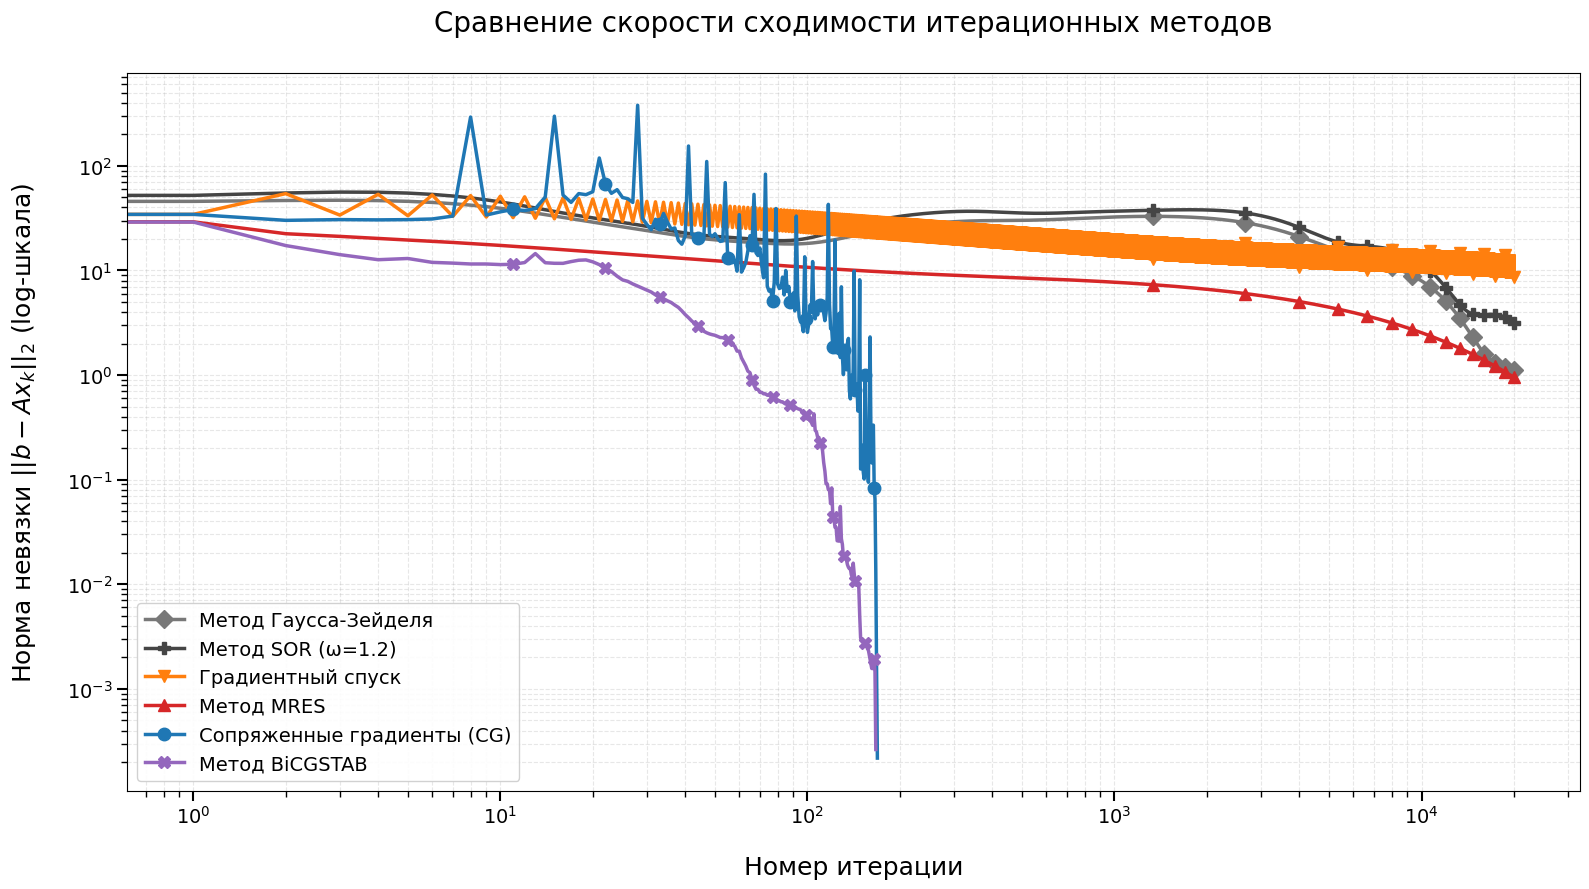

In [42]:
residual_data = {
    # "jacobi": r_norm_arr_jacobi,
    "seidel": r_norm_arr_seidel,
    "sor": r_norm_arr_sor,
    "gradient_descent": r_norm_arr_gradient_descent,
    "mres": r_norm_arr_mres,
    "conjugate_gradient": r_norm_arr_conjugate_gradient,
    "bicgstab": r_norm_arr_bicgstab,
}

method_styles = {
    "jacobi":             {"color": "#a6a6a6", "marker": "s", "label": "Метод Якоби"},
    "seidel":             {"color": "#787878", "marker": "D", "label": "Метод Гаусса-Зейделя"},
    "sor":                {"color": "#454545", "marker": "P", "label": f"Метод SOR (ω={omega_sor})"},
    "gradient_descent":   {"color": "#ff7f0e", "marker": "v", "label": "Градиентный спуск"},
    "mres":               {"color": "#d62728", "marker": "^", "label": "Метод MRES"},
    "bicgstab":           {"color": "#9467bd", "marker": "X", "label": "Метод BiCGSTAB"},
    "conjugate_gradient": {"color": "#1f77b4", "marker": "o", "label": "Сопряженные градиенты (CG)"},
}

# Cловарь для хранения объектов PlotParams
plot_params_dict = {}

# Заполняем словарь, создавая параметры для каждого метода
for method_name, residuals in residual_data.items():
    if not residuals: continue # Пропускаем, если метод не вернул данных
    
    style = method_styles[method_name]
    # Рассчитываем markevery для каждого графика индивидуально, чтобы не было слишком много маркеров
    markevery_i = max(1, int(len(residuals) / 15))

    plot_params_dict[method_name] = PlotParams(
        linestyle="-",
        color=style["color"],
        linewidth=2.5,
        marker=style["marker"],
        markersize=9,
        markevery=markevery_i,
        label=style["label"]
    )
plotter = Plotter(
    title="Сравнение скорости сходимости итерационных методов",
    xlabel="Номер итерации",
    ylabel=r"Норма невязки $||b - Ax_k||_2$ (log-шкала)"
)

# В цикле добавляем графики на холст
for method_name, residuals in residual_data.items():
    if not residuals: continue

    iterations = np.arange(len(residuals))
    residuals_np = np.array(residuals)
    
    plotter.add_plot(iterations, residuals_np, plot_params_dict[method_name])

plotter.ax.set_yscale('log')
plotter.ax.set_xscale('log')

# if plotter.ax.get_ylim()[0] < 1e-12:
#     plotter.ax.set_ylim(bottom=1e-12)

plotter.finalize_and_show()


In [43]:
# Матрица из пункта д!!!

n = 100
a = 10

b = np.arange(1, n + 1)


A = np.ones((n, n), dtype=np.float64)
A -= np.triu(np.ones((n, n), dtype=np.float64), k=5)
A -= np.tril(np.ones((n, n), dtype=np.float64), k=-5)
np.fill_diagonal(A, a)

print(A[:20, :20])
print(b)

[[10.  1.  1.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 1. 10.  1.  1.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 1.  1. 10.  1.  1.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 1.  1.  1. 10.  1.  1.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 1.  1.  1.  1. 10.  1.  1.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1.  1.  1.  1. 10.  1.  1.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  1.  1.  1. 10.  1.  1.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  1.  1.  1. 10.  1.  1.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  1.  1.  1. 10.  1.  1.  1.  1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  1.  1.  1.  1. 10.  1.  1.  1.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  1.  1.  1. 10.  1.  1.  1.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1.  1.  1.  1. 10.  1.  1.  1.  1.  0.  0.  0.  0.]
 [ 0

In [44]:
# --- 1.1. Генерация случайной системы ---
# n = np.random.randint(4, 7)
# A_gen = np.random.rand(n, n) * 10
# b_gen = np.random.rand(n) * 10

A_gen = A.copy()
b_gen = b.copy()
n = n

# print(f"\nСистема A x = b размерности {n}x{n}")
# print("Матрица A:\n", np.round(A_gen, 3))
# print("\nВектор b:\n", np.round(b_gen, 3))
# print("="*60, "\n")


# --- 1.2. С вероятностью 20% делаем матрицу вырожденной ---
# if np.random.rand() < 0.2 and n > 2:
#     print("!!! ВНИМАНИЕ: Матрица искусственно сделана ВЫРОЖДЕННОЙ. !!!\n")
#     row_to_replace = np.random.randint(0, n)
#     other_rows = np.delete(np.arange(n), row_to_replace)
#     r1, r2 = np.random.choice(other_rows, 2, replace=False)
#     A_gen[row_to_replace, :] = A_gen[r1, :] * 1.5 - A_gen[r2, :] * 0.5


# --- 1.3. Решение методами для матриц общего вида ---
x_gen_np, x_gen_gauss, x_gen_lu, x_gen_jacobi, x_gen_seidel, x_gen_sor, x_gen_bicgstab = [None] * 7
max_iters = 20000 

print("-" * 50)
print("Решение с помощью np.linalg.solve (Эталон):")
try:
    start_time = time.perf_counter()
    x_gen_np = np.linalg.solve(A_gen, b_gen)
    end_time = time.perf_counter()
    print(f"  Решение: {x_gen_np}")
    print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
except np.linalg.LinAlgError as e:
    print(f"  ОШИБКА: {e}")
print("-" * 50)

# -- Прямые методы --
print("Решение методом Гаусса:")
try:
    start_time = time.perf_counter()
    x_gen_gauss = solve_gauss(A_gen.copy(), b_gen.copy(), pivoting='full')
    end_time = time.perf_counter()
    print(f"  Решение: {x_gen_gauss}")
    print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
except (ValueError, np.linalg.LinAlgError) as e:
    print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение с помощью LU-разложения:")
try:
    start_time = time.perf_counter()
    P, L, U = lu_factor(A_gen.copy()) 
    x_gen_lu = solve_lu((P, L, U), b_gen.copy())
    end_time = time.perf_counter()
    print(f"  Решение: {x_gen_lu}")
    print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
except (ValueError, np.linalg.LinAlgError) as e:
    print(f"  ОШИБКА: {e}")
print("-" * 50)

# -- Итерационные методы --
print("Решение методом Якоби:")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_gen_jacobi, info, r_norm_arr_jacobi = solve_jacobi(A_gen.copy(), b_gen.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_gen_jacobi}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение методом Гаусса-Зейделя:")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_gen_seidel, info, r_norm_arr_seidel = solve_seidel(A_gen.copy(), b_gen.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_gen_seidel}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение методом SOR (omega=1.2):")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_gen_sor, info, r_norm_arr_sor = solve_sor(A_gen.copy(), b_gen.copy(), omega=1.2, maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_gen_sor}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение методом BiCGSTAB:")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_gen_bicgstab, info, r_norm_arr_bicgstab = solve_bicgstab(A_gen.copy(), b_gen.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_gen_bicgstab}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

# --- 1.4. Итоговое сравнение для матрицы общего вида ---
print("\nСравнение результатов (Блок 1) с эталоном np.linalg.solve:")
if x_gen_np is not None:
    if x_gen_gauss is not None: print(f"  Гаусс совпадает:       {np.allclose(x_gen_np, x_gen_gauss)}")
    if x_gen_lu is not None: print(f"  LU совпадает:             {np.allclose(x_gen_np, x_gen_lu)}")
    if x_gen_jacobi is not None: print(f"  Якоби совпадает:      {np.allclose(x_gen_np, x_gen_jacobi, rtol=1e-3)}")
    if x_gen_seidel is not None: print(f"  Зейдель совпадает:    {np.allclose(x_gen_np, x_gen_seidel, rtol=1e-3)}")
    if x_gen_sor is not None: print(f"  SOR совпадает:           {np.allclose(x_gen_np, x_gen_sor, rtol=1e-3)}")
    if x_gen_bicgstab is not None: print(f"  BiCGSTAB совпадает: {np.allclose(x_gen_np, x_gen_bicgstab, rtol=1e-3)}")
else:
    print("  Эталонное решение не найдено. Сравнение невозможно.")

print("\n" * 3)

--------------------------------------------------
Решение с помощью np.linalg.solve (Эталон):
  Решение: [0.0229214  0.09689605 0.16487571 0.22670602 0.28230826 0.33422809 0.38818309 0.44352717 0.49957984 0.55564296 0.61130107 0.66677899 0.722232
 0.77774012 0.83330511 0.88888183 0.94445003 1.00000675 1.05555813 1.11111052 1.16666527 1.22222144 1.27777775 1.3333336  1.38888909 1.44444449
 1.49999996 1.55555551 1.61111109 1.66666667 1.72222223 1.77777778 1.83333333 1.88888889 1.94444444 2.         2.05555556 2.11111111 2.16666667
 2.22222222 2.27777778 2.33333333 2.38888889 2.44444444 2.5        2.55555556 2.61111111 2.66666667 2.72222222 2.77777778 2.83333333 2.88888889
 2.94444444 3.         3.05555555 3.11111111 3.16666667 3.22222222 3.27777778 3.33333334 3.38888888 3.44444442 3.49999998 3.55555557 3.61111119
 3.6666668  3.72222225 3.77777748 3.8333327  3.88888846 3.94444536 4.00000287 4.05555861 4.11110933 4.16665466 4.22220464 4.27777582 4.33337627
 4.38898044 4.44449555 4.4998623

In [45]:
# --- 2.1. Генерация SPD матрицы ---

# Не факт, что A - SPD, но попробуем на ней наши методы
n_spd = n
A_spd = A.copy()
b_spd = b.copy()

# print(f"\nСгенерирована SPD система A x = b размерности {n_spd}x{n_spd}")
# print("Матрица A:\n", np.round(A_spd, 3))
# print("\nВектор b:\n", np.round(b_spd, 3))
# print("="*60, "\n")


# --- 2.2. Решение всеми существующими методами ---
x_spd_np, x_spd_gauss, x_spd_lu, x_spd_jacobi, x_spd_seidel, x_spd_sor, \
x_spd_gd, x_spd_mres, x_spd_cg, x_spd_bicgstab = [None] * 10
max_iters = 20000

# -- NumPy (Эталон) --
print("-" * 50)
print("Решение с помощью np.linalg.solve (Эталон):")
try:
    start_time = time.perf_counter()
    x_spd_np = np.linalg.solve(A_spd, b_spd)
    end_time = time.perf_counter()
    print(f"  Решение: {x_spd_np}")
    print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
except np.linalg.LinAlgError as e:
    print(f"  ОШИБКА: {e}")
print("-" * 50)

# -- Прямые методы --
print("Решение методом Гаусса:")
try:
    start_time = time.perf_counter()
    x_spd_gauss = solve_gauss(A_spd.copy(), b_spd.copy(), pivoting='full')
    end_time = time.perf_counter()
    print(f"  Решение: {x_spd_gauss}")
    print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
except (ValueError, np.linalg.LinAlgError) as e:
    print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение с помощью LU-разложения:")
try:
    start_time = time.perf_counter()
    P, L, U = lu_factor(A_spd.copy()) 
    x_spd_lu = solve_lu((P, L, U), b_spd.copy())
    end_time = time.perf_counter()
    print(f"  Решение: {x_spd_lu}")
    print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
except (ValueError, np.linalg.LinAlgError) as e:
    print(f"  ОШИБКА: {e}")
print("-" * 50)

# -- Классические итерационные методы --
print("Решение методом Якоби:")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_spd_jacobi, info, r_norm_arr_jacobi = solve_jacobi(A_spd.copy(), b_spd.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_spd_jacobi}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение методом Гаусса-Зейделя:")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_spd_seidel, info, r_norm_arr_seidel = solve_seidel(A_spd.copy(), b_spd.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_spd_seidel}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

omega_sor = 1.2

print(f"Решение методом SOR (omega={omega_sor}):")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_spd_sor, info, r_norm_arr_sor = solve_sor(A_spd.copy(), b_spd.copy(), omega=omega_sor, maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_spd_sor}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

# -- Специализированные итерационные методы --
print("Решение методом градиентного спуска (GD):")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_spd_gd, info, r_norm_arr_gradient_descent = solve_gradient_descent(A_spd.copy(), b_spd.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_spd_gd}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение методом минимальных невязок (MRES):")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_spd_mres, info, r_norm_arr_mres = solve_mres(A_spd.copy(), b_spd.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_spd_mres}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение методом сопряженных градиентов (CG):")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_spd_cg, info, r_norm_arr_conjugate_gradient = solve_conjugate_gradient(A_spd.copy(), b_spd.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_spd_cg}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)

print("Решение методом BiCGSTAB:")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    try:
        start_time = time.perf_counter()
        x_spd_bicgstab, info, r_norm_arr_bicgstab = solve_bicgstab(A_spd.copy(), b_spd.copy(), maxiter=max_iters)
        end_time = time.perf_counter()
        status = f"сошлось за {info} итераций" if info > 0 else f"НЕ сошлось за {max_iters} итераций"
        print(f"  Решение: {x_spd_bicgstab}")
        print(f"  Статус: {status}")
        print(f"  Время: {(end_time - start_time)*1000:.4f} мс")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  ОШИБКА: {e}")
print("-" * 50)


# --- 2.3. Итоговое сравнение для SPD матрицы ---
print("\nСравнение результатов с np.linalg.solve:")
if x_spd_np is not None:
    if x_spd_gauss is not None: print(f"  Гаусс совпадает:                      {np.allclose(x_spd_np, x_spd_gauss)}")
    if x_spd_lu is not None:    print(f"  LU совпадает:                         {np.allclose(x_spd_np, x_spd_lu)}")
    if x_spd_jacobi is not None:   print(f"  Якоби совпадает:                      {np.allclose(x_spd_np, x_spd_jacobi,   rtol=1e-1)}")
    if x_spd_seidel is not None:   print(f"  Гаусс-Зейдель совпадает:              {np.allclose(x_spd_np, x_spd_seidel,   rtol=1e-1)}")
    if x_spd_sor is not None:      print(f"  SOR совпадает:                        {np.allclose(x_spd_np, x_spd_sor,      rtol=1e-1)}")
    if x_spd_gd is not None:       print(f"  Градиентный спуск (GD) совпадает:     {np.allclose(x_spd_np, x_spd_gd,       rtol=1e-1)}")
    if x_spd_mres is not None:     print(f"  Мин. невязки (MRES) совпадает:        {np.allclose(x_spd_np, x_spd_mres,     rtol=1e-1)}")
    if x_spd_cg is not None:       print(f"  Сопряженные градиенты (CG) совпадает: {np.allclose(x_spd_np, x_spd_cg,       rtol=1e-1)}")
    if x_spd_bicgstab is not None: print(f"  BiCGSTAB совпадает:                   {np.allclose(x_spd_np, x_spd_bicgstab, rtol=1e-1)}")
else:
    print("  Эталонное решение не найдено. Сравнение невозможно.")



--------------------------------------------------
Решение с помощью np.linalg.solve (Эталон):
  Решение: [0.0229214  0.09689605 0.16487571 0.22670602 0.28230826 0.33422809 0.38818309 0.44352717 0.49957984 0.55564296 0.61130107 0.66677899 0.722232
 0.77774012 0.83330511 0.88888183 0.94445003 1.00000675 1.05555813 1.11111052 1.16666527 1.22222144 1.27777775 1.3333336  1.38888909 1.44444449
 1.49999996 1.55555551 1.61111109 1.66666667 1.72222223 1.77777778 1.83333333 1.88888889 1.94444444 2.         2.05555556 2.11111111 2.16666667
 2.22222222 2.27777778 2.33333333 2.38888889 2.44444444 2.5        2.55555556 2.61111111 2.66666667 2.72222222 2.77777778 2.83333333 2.88888889
 2.94444444 3.         3.05555555 3.11111111 3.16666667 3.22222222 3.27777778 3.33333334 3.38888888 3.44444442 3.49999998 3.55555557 3.61111119
 3.6666668  3.72222225 3.77777748 3.8333327  3.88888846 3.94444536 4.00000287 4.05555861 4.11110933 4.16665466 4.22220464 4.27777582 4.33337627
 4.38898044 4.44449555 4.4998623

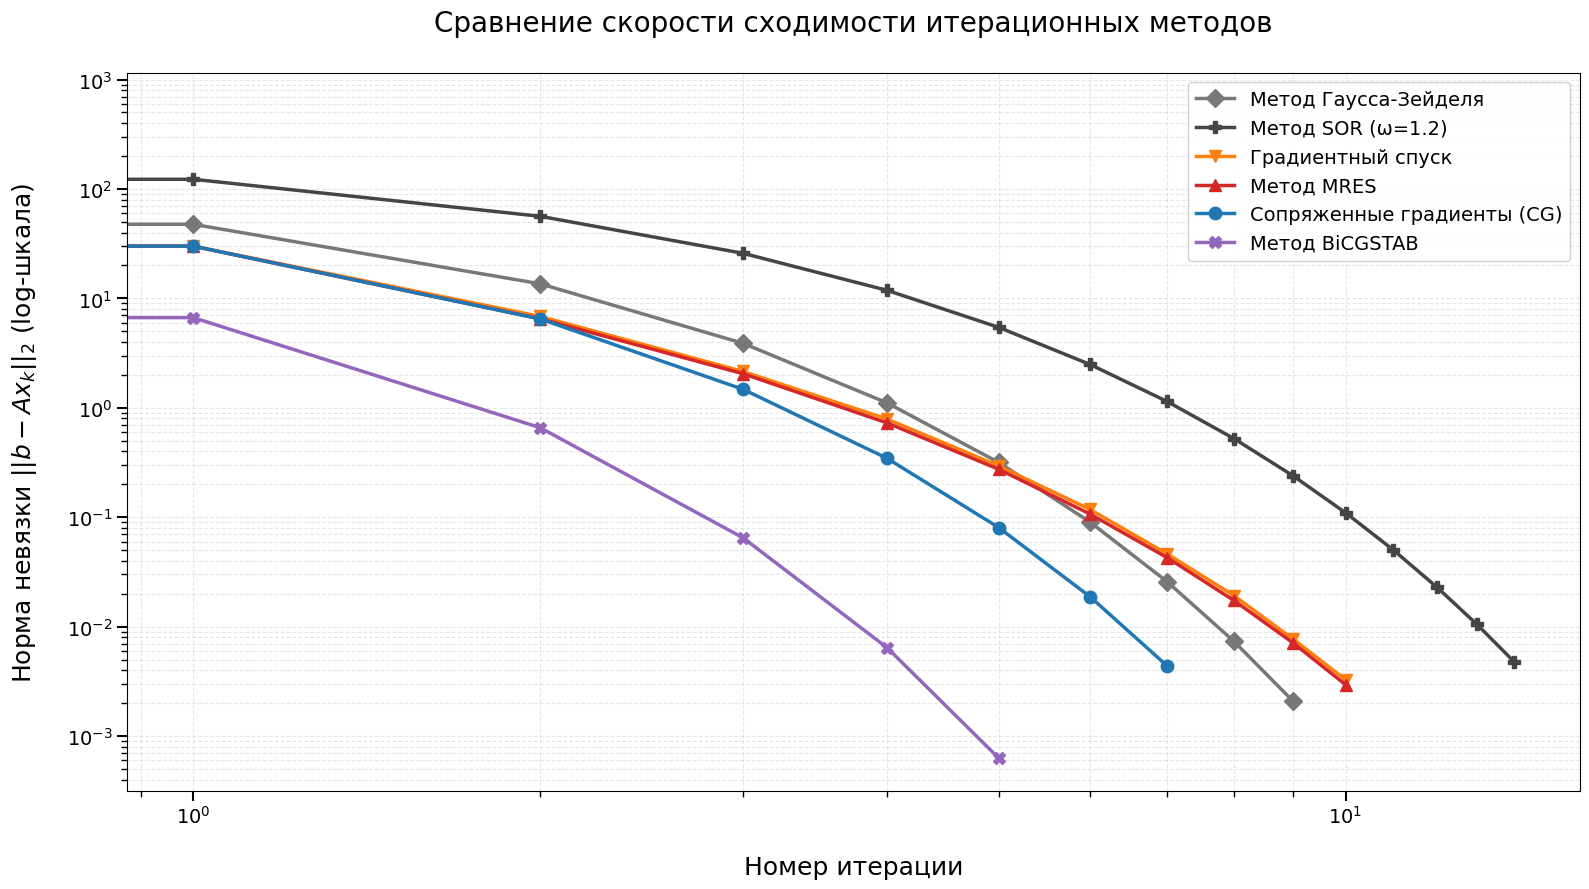

In [46]:
residual_data = {
    # "jacobi": r_norm_arr_jacobi,
    "seidel": r_norm_arr_seidel,
    "sor": r_norm_arr_sor,
    "gradient_descent": r_norm_arr_gradient_descent,
    "mres": r_norm_arr_mres,
    "conjugate_gradient": r_norm_arr_conjugate_gradient,
    "bicgstab": r_norm_arr_bicgstab,
}

method_styles = {
    "jacobi":             {"color": "#a6a6a6", "marker": "s", "label": "Метод Якоби"},
    "seidel":             {"color": "#787878", "marker": "D", "label": "Метод Гаусса-Зейделя"},
    "sor":                {"color": "#454545", "marker": "P", "label": f"Метод SOR (ω={omega_sor})"},
    "gradient_descent":   {"color": "#ff7f0e", "marker": "v", "label": "Градиентный спуск"},
    "mres":               {"color": "#d62728", "marker": "^", "label": "Метод MRES"},
    "bicgstab":           {"color": "#9467bd", "marker": "X", "label": "Метод BiCGSTAB"},
    "conjugate_gradient": {"color": "#1f77b4", "marker": "o", "label": "Сопряженные градиенты (CG)"},
}

# Cловарь для хранения объектов PlotParams
plot_params_dict = {}

# Заполняем словарь, создавая параметры для каждого метода
for method_name, residuals in residual_data.items():
    if not residuals: continue # Пропускаем, если метод не вернул данных
    
    style = method_styles[method_name]
    # Рассчитываем markevery для каждого графика индивидуально, чтобы не было слишком много маркеров
    markevery_i = max(1, int(len(residuals) / 15))

    plot_params_dict[method_name] = PlotParams(
        linestyle="-",
        color=style["color"],
        linewidth=2.5,
        marker=style["marker"],
        markersize=9,
        markevery=markevery_i,
        label=style["label"]
    )
plotter = Plotter(
    title="Сравнение скорости сходимости итерационных методов",
    xlabel="Номер итерации",
    ylabel=r"Норма невязки $||b - Ax_k||_2$ (log-шкала)"
)

# В цикле добавляем графики на холст
for method_name, residuals in residual_data.items():
    if not residuals: continue

    iterations = np.arange(len(residuals))
    residuals_np = np.array(residuals)
    
    plotter.add_plot(iterations, residuals_np, plot_params_dict[method_name])

plotter.ax.set_yscale('log')
plotter.ax.set_xscale('log')

# if plotter.ax.get_ylim()[0] < 1e-12:
#     plotter.ax.set_ylim(bottom=1e-12)

plotter.finalize_and_show()
